In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay)
from utils import load_data

X_train, X_test, y_train, y_test = load_data()

In [ ]:
# 1. One-Hot Encoding 
# Same reason as Linear Regression — logistic regression treats
# inputs as continuous, so fake numeric ordering must be avoided
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
X_train_enc = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

#  2. Feature Scaling 
# The sigmoid function wraps around z = w1*x1 + w2*x2 + ...
# If MonthlyIncome has values in thousands, its weight will be
# tiny to compensate, making training unstable and slow.
# Scaling puts all features on equal footing.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

C:\Users\shrad\AppData\Local\Temp\ipykernel_20904\256489927.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns.tolist()


In [ ]:
# 3. Train — baseline (no class weight) 
# First, let's see what happens WITHOUT handling class imbalance
model_baseline = LogisticRegression(random_state=42, max_iter=1000)
model_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = model_baseline.predict(X_test_scaled)

print("── Baseline (no class weight handling) ──")
print(classification_report(y_test, y_pred_baseline, target_names=["No", "Yes"]))

# 4. Train — with class weight balanced 
# class_weight='balanced' makes the model penalize errors on the
# minority class (attrition=Yes) proportionally more.
model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred       = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of Yes

print("\n── With class_weight='balanced' ──")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

── Baseline (no class weight handling) ──
              precision    recall  f1-score   support

          No       0.88      0.96      0.92       247
         Yes       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294


── With class_weight='balanced' ──
              precision    recall  f1-score   support

          No       0.91      0.78      0.84       247
         Yes       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [ ]:
# 5. ROC Curve & AUC 
# ROC curve shows tradeoff between True Positive Rate and False Positive Rate
# at every possible threshold (not just 0.5).
# AUC (Area Under Curve): 0.5 = random, 1.0 = perfect
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {auc:.4f}")


ROC-AUC Score: 0.7983


In [ ]:
# 6. Threshold tuning 
# Default threshold is 0.5 but with imbalanced data, lowering it
# catches more actual attrition cases (higher recall) at the cost
# of more false alarms (lower precision).
# Let's find the threshold that maximizes F1 for the minority class.
f1_scores = []
threshold_range = np.arange(0.1, 0.9, 0.01)

for t in threshold_range:
    y_temp = (y_pred_proba >= t).astype(int)
    from sklearn.metrics import f1_score
    f1_scores.append(f1_score(y_test, y_temp, pos_label=1, zero_division=0))

best_threshold = threshold_range[np.argmax(f1_scores)]
print(f"Best threshold for F1: {best_threshold:.2f}")

y_pred_tuned = (y_pred_proba >= best_threshold).astype(int)
print("\n── With tuned threshold ──")
print(classification_report(y_test, y_pred_tuned, target_names=["No", "Yes"]))

Best threshold for F1: 0.39

── With tuned threshold ──
              precision    recall  f1-score   support

          No       0.95      0.73      0.83       247
         Yes       0.37      0.81      0.50        47

    accuracy                           0.74       294
   macro avg       0.66      0.77      0.67       294
weighted avg       0.86      0.74      0.78       294



In [ ]:
# 7. Feature coefficients 
# In logistic regression, coefficients are in log-odds space.
# Positive coefficient - increases probability of attrition
# Negative coefficient - decreases probability of attrition
# Larger absolute value - stronger influence
feature_names = X_train_enc.columns
coef_series = pd.Series(model.coef_[0], index=feature_names)
top_pos = coef_series.nlargest(10)
top_neg = coef_series.nsmallest(10)
top_features = pd.concat([top_pos, top_neg])

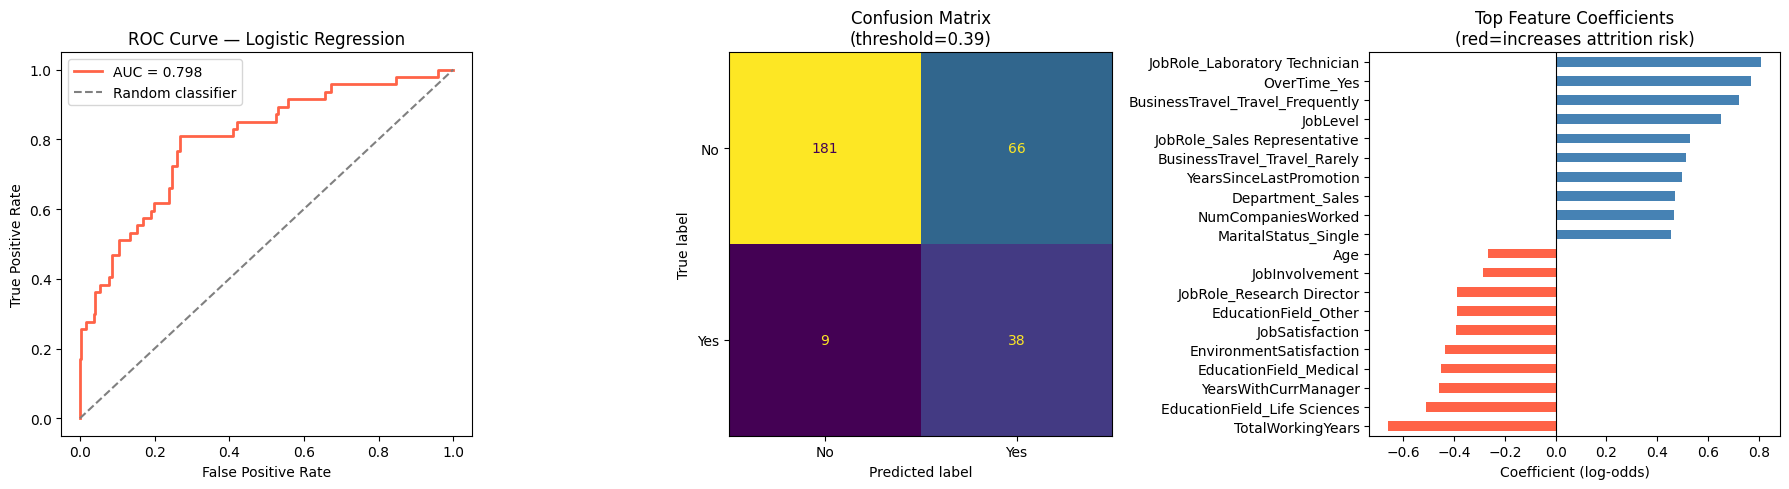

In [ ]:

#  8. Plots 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: ROC Curve
axes[0].plot(fpr, tpr, color="tomato", lw=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random classifier")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Logistic Regression")
axes[0].legend()

# Plot 2: Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion Matrix\n(threshold={best_threshold:.2f})")

# Plot 3: Top feature coefficients
colors = ["tomato" if c > 0 else "steelblue" for c in top_features.values]
top_features.sort_values().plot(kind="barh", ax=axes[2], color=colors)
axes[2].set_title("Top Feature Coefficients\n(red=increases attrition risk)")
axes[2].set_xlabel("Coefficient (log-odds)")
axes[2].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()